In [6]:
import numpy as np

class GaussianNaiveBayes:
    def fit(self,X,Y):
        n_samples,n_features = X.shape
        self.classes = np.unique(Y)
        n_classes = len(self.classes)

        self.mean = np.zeros((n_classes,n_features),dtype=np.float64)
        self.var = np.zeros((n_classes,n_features),dtype=np.float64)
        self.priors = np.zeros(n_classes,dtype=np.float64)

        for idx,c in enumerate(self.classes):
            X_c = X[Y==c]

            self.mean[idx,:] = X_c.mean(axis=0)
            self.var[idx,:] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0]/float(n_samples)

    def predict(self,X):
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self,x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            # 1. Start with log( P(y=c_k) )
            log_prior = np.log(self.priors[idx])
            
            # 2. Compute log( P(x_j | y=c_k) ) directly for numerical stability
            # Math: -0.5 * log(2 * pi * var) - ((x - mean)^2 / (2 * var))
            mean = self.mean[idx]
            var = self.var[idx]
            
            log_pdf = -0.5 * np.log(2 * np.pi * var) - ((x - mean)**2 / (2 * var))
            
            # 3. Sum the log likelihoods: sum( log( P(x_j | y=c_k) ) )
            log_likelihood = np.sum(log_pdf)
            
            # 4. Total log posterior score (Equation from Section 2.4)
            posterior = log_prior + log_likelihood
            posteriors.append(posterior)
            
        # Return the class with the maximum posterior probability (argmax)
        print(posteriors)
        return self.classes[np.argmax(posteriors)]

In [7]:
# Synthetic Data
X_train = np.array([
    [22.0, 45.0], # Nice weather -> Run (1)
    [25.0, 50.0], # Nice weather -> Run (1)
    [21.0, 48.0], # Nice weather -> Run (1)
    [35.0, 85.0], # Hot & humid -> Stay (0)
    [38.0, 90.0], # Hot & humid -> Stay (0)
    [10.0, 95.0]  # Cold & humid -> Stay (0)
])
y_train = np.array([1, 1, 1, 0, 0, 0])

# Test data (28C and 70% humidity)
X_test = np.array([[28.0, 70.0]])

# --- OUR FROM-SCRATCH MODEL ---
nb_scratch = GaussianNaiveBayes()
nb_scratch.fit(X_train, y_train)
pred_scratch = nb_scratch.predict(X_test)
print(f"Scratch Prediction: {pred_scratch[0]}")

# --- SCIKIT-LEARN MODEL ---
from sklearn.naive_bayes import GaussianNB
nb_sklearn = GaussianNB(var_smoothing=1e-9)
nb_sklearn.fit(X_train, y_train)
pred_sklearn = nb_sklearn.predict(X_test)
print(f"Sklearn Prediction: {pred_sklearn[0]}")

[np.float64(-18.46797127953612), np.float64(-67.77050741526816)]
Scratch Prediction: 0
Sklearn Prediction: 0


[np.float64(-251.89674419914118), np.float64(-361.77050741526807)]
[np.float64(-251.80930464117245), np.float64(-357.8714217278437)]
[np.float64(-251.72346781231658), np.float64(-354.0597464204991)]
[np.float64(-251.63923371257363), np.float64(-350.3354814932343)]
[np.float64(-251.55660234194355), np.float64(-346.69862694604916)]
[np.float64(-251.47557370042637), np.float64(-343.14918277894384)]
[np.float64(-251.39614778802206), np.float64(-339.68714899191826)]
[np.float64(-251.31832460473066), np.float64(-336.31252558497243)]
[np.float64(-251.24210415055214), np.float64(-333.02531255810635)]
[np.float64(-251.1674864254865), np.float64(-329.82550991132007)]
[np.float64(-251.09447142953374), np.float64(-326.71311764461353)]
[np.float64(-251.02305916269387), np.float64(-323.68813575798674)]
[np.float64(-250.95324962496687), np.float64(-320.7505642514397)]
[np.float64(-250.88504281635278), np.float64(-317.9004031249724)]
[np.float64(-250.8184387368516), np.float64(-315.13765237858485)]
[n

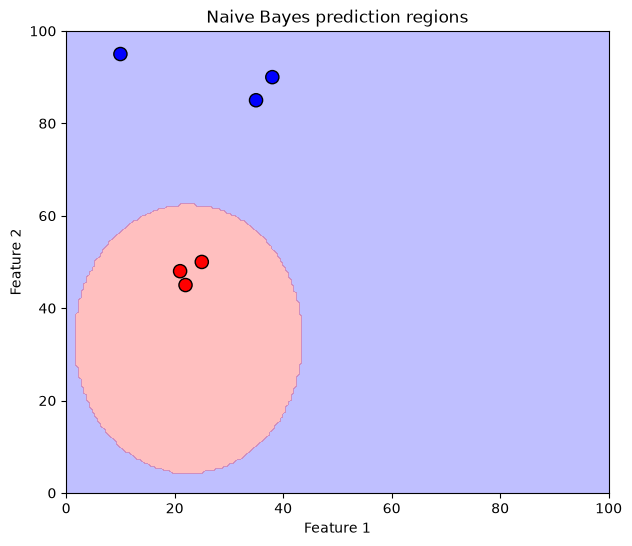

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Create a grid from 0 to 100 for both features
x1_vals = np.linspace(0, 100, 200)
x2_vals = np.linspace(0, 100, 200)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

# Make a list of points on the grid
grid_points = np.column_stack([xx1.ravel(), xx2.ravel()])

# Predict the class for each grid point
grid_pred = nb_scratch.predict(grid_points)
grid_pred = grid_pred.reshape(xx1.shape)

# Plot the decision regions
cmap = ListedColormap(['blue', 'red'])

plt.figure(figsize=(7, 6))
plt.contourf(xx1, xx2, grid_pred, alpha=0.25, cmap=cmap, levels=[-0.5, 0.5, 1.5])

# Plot the training points
# Use true labels for coloring, or replace with predicted labels if you want
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, s=90, edgecolors='k')

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Naive Bayes prediction regions")
plt.show()